# 深度学习课程设计报告

## 一、封面

- 课程名称：深度学习
- 设计题目：基于深度学习的交通标志图像分类
- 姓    名：谢跃望
- 学    号：20234080211
- 班    级：本23数据02班
- 指导教师：丁平尖
- 提交日期：2026年6月26日


## 二、摘要

本课程设计完成一套交通标志图像分类实验。数据来自kaggle提供的 `archive` 数据集：原始标注 6164 条、58 类；经清洗后可用图像 1621 张，实验取其中 12 类（编号 0–11），以限速牌和常见禁令牌为主。
数据源网址：https://www.kaggle.com/datasets/dmitryyemelyanov/chinese-traffic-signs/data

实验分两条线对比。**Baseline** 使用自行编写的 `BaselineCNN`（5 级卷积 + BatchNorm + Dropout），不调用现成骨干网络，不加载预训练权重，在本数据集上从零训练 25 个 Epoch，验证集最佳准确率 **97.13%**。**EfficientNet-B0** 采用 ImageNet 预训练权重微调，同样训练 25 个 Epoch，验证集准确率达到 **100%**。

从训练曲线看，EfficientNet-B0 在前几个 Epoch 就趋于稳定，Baseline 则需要更长时间才爬升到相近水平，说明预训练对收敛速度帮助明显。报告后文给出数据预处理细节、网络结构、超参数、两组损失/精度曲线、混淆矩阵和错例分析，代码均在 notebook 中可直接运行。


## 三、问题定义与需求分析

### 3.1 项目背景与意义

路上常见的交通标志形状、颜色都比较固定，但实拍图像并不“干净”：距离远近不同、标志在画面里占的大小不一样、阴天逆光、树影遮挡、摄像头抖动都会影响识别效果。早期做法多依赖 SIFT、HOG 等手工特征，需要人工设计描述子，换一批拍摄条件往往就要重新调参，维护成本较高。

卷积神经网络可以直接从像素中学习特征，比手工特征更省事。本课题主要完成四件事：整理标注数据并裁剪 ROI；设计并训练自定义 Baseline；用 EfficientNet-B0 做迁移学习对照；用曲线和混淆矩阵检查模型效果。

### 3.2 问题描述

| 项目 | 说明 |
|------|------|
| 输入 | RGB 图像；按标注框裁剪标志区域，缩放到 128×128，ImageNet 归一化 |
| 输出 | 12 类标志的类别 ID（0–11），Softmax 取最大概率类 |
| 任务 | 多分类图像分类，每张图一个标签 |
| 训练集 / 验证集 | 85% / 15%，分层抽样，`random_state=42` |
| 目标准确率 | 验证集 Accuracy ≥ 95%，并检查各类 F1 |

限速牌之间数字形状接近，是最容易混淆的一类，因此除了总准确率，还要查看混淆矩阵和错例图。


In [1]:
import os
import random
import platform
import sys
from collections import Counter
from pathlib import Path

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from PIL import Image, ImageFile
from torch.utils.data import Dataset, DataLoader, random_split
from torchvision import models, transforms
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report

ImageFile.LOAD_TRUNCATED_IMAGES = False

# ---------- 全局配置 ----------
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

plt.rcParams["font.sans-serif"] = ["SimHei", "Microsoft YaHei", "DejaVu Sans"]
plt.rcParams["axes.unicode_minus"] = False

DATA_ROOT = Path("archive")
IMG_DIR = DATA_ROOT / "images"
ANNOT_PATH = DATA_ROOT / "annotations.csv"
IMG_SIZE = 128
USE_AMP = device.type == "cuda"

CLASS_NAMES = {
    0: "限速20", 1: "限速30", 2: "限速50", 3: "限速60", 4: "限速70",
    5: "限速80", 6: "解除限速80", 7: "限速100", 8: "限速120", 9: "禁止超车",
    10: "禁止三轴以上超车", 11: "前方让行", 12: "停车让行", 13: "让行主路",
    14: "停车", 15: "禁止通行", 16: "禁止三轴以上通行", 17: "禁止驶入",
    18: "通用警告", 19: "左侧急弯", 20: "右侧急弯", 21: "连续弯道",
    22: "颠簸路", 23: "湿滑路", 24: "右侧变窄", 25: "施工", 26: "注意信号灯",
    27: "注意行人", 28: "注意儿童", 29: "注意自行车", 30: "注意冰雪",
    31: "注意野生动物", 32: "解除限速", 33: "禁止右转", 34: "禁止左转",
    35: "禁止掉头", 36: "禁止直行", 37: "禁止直行右转", 38: "禁止直行左转",
    39: "禁止左转右转", 40: "禁止超车(解除)", 41: "禁止三轴以上超车(解除)",
    42: "强制右转", 43: "强制左转", 44: "强制直行", 45: "强制直行右转",
    46: "强制直行左转", 47: "强制左侧通行", 48: "强制右侧通行", 49: "环形让行",
    50: "优先通行", 51: "让行对向", 52: "禁止停车", 53: "禁止临时停车",
    54: "注意两方向", 55: "禁止危险品", 56: "禁止鸣笛", 57: "其他标志",
}


def label_name(cat_id):
    return CLASS_NAMES.get(int(cat_id), f"类别{int(cat_id)}")


def load_valid_records():
    df = pd.read_csv(ANNOT_PATH)
    existing = set(os.listdir(IMG_DIR))
    df = df[df["file_name"].isin(existing)].drop_duplicates("file_name").reset_index(drop=True)

    records = []
    skipped = 0
    for _, row in df.iterrows():
        path = IMG_DIR / row["file_name"]
        try:
            with Image.open(path) as im:
                im.verify()
            with Image.open(path) as im:
                im.load()
                img = im.convert("RGB")
                w, h = img.size
        except Exception:
            skipped += 1
            continue

        x1, y1, x2, y2 = map(int, [row["x1"], row["y1"], row["x2"], row["y2"]])
        x1c, y1c = max(0, x1 - 2), max(0, y1 - 2)
        x2c, y2c = min(w, x2 + 2), min(h, y2 + 2)
        if x2c <= x1c or y2c <= y1c:
            skipped += 1
            continue

        records.append({
            "file_name": row["file_name"],
            "path": str(path),
            "category": int(row["category"]),
            "x1": x1, "y1": y1, "x2": x2, "y2": y2,
            "width": w, "height": h,
            "crop": img.crop((x1c, y1c, x2c, y2c)),
        })

    print(f"标注总数: {len(pd.read_csv(ANNOT_PATH))}")
    print(f"可用图像: {len(records)} | 跳过: {skipped}")
    return records


records = load_valid_records()
df_records = pd.DataFrame(records)
categories = sorted(df_records["category"].unique())
cat_to_idx = {c: i for i, c in enumerate(categories)}
idx_to_cat = {i: c for c, i in cat_to_idx.items()}
class_names = [label_name(idx_to_cat[i]) for i in range(len(categories))]
num_classes = len(categories)
total_samples = len(records)
print(f"类别数: {num_classes} | 类别ID: {categories}")


Using device: cuda
标注总数: 6164
可用图像: 1621 | 跳过: 3
类别数: 12 | 类别ID: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11]


## 四、数据集说明与预处理

### 4.1 数据来源与规模

- **来源：** 课程提供的 `archive.zip`，解压后包含 `annotations.csv` 与 `images/` 目录。
- **标注字段：** `file_name`（文件名）、`width/height`（原图尺寸）、`x1,y1,x2,y2`（标志框）、`category`（类别 ID）。格式与 GTSRB（德国交通标志数据集）相近，属于“整张图 + 框 + 类别”的监督标注。
- **原始规模：** 6164 条记录，文件名前缀 000–057 对应 58 个细分类别。
- **本实验子集：** 本地 `images/` 目录下能正常打开的图像共 1621 张；与标注对齐并去掉坏框、重复文件名后，保留 12 个类别。各类样本数不完全均衡，限速 60（类别 3）样本最多，个别类别只有 2 张，训练时对损失函数做了类别加权。

下面代码会打印各类别具体数量和占比，并给出样例图、分辨率分布，便于直观感受数据特点。


In [2]:
print("=== 4.1 数据来源与规模 ===")
print(f"有效样本总量: {total_samples}")
print(f"类别数量: {num_classes}")
print("\n类别分布:")
class_counts = df_records["category"].value_counts().sort_index()
for cat, cnt in class_counts.items():
    print(f"  [{cat:02d}] {label_name(cat)}: {cnt} 张 ({cnt/total_samples*100:.2f}%)")


=== 4.1 数据来源与规模 ===
有效样本总量: 1621
类别数量: 12

类别分布:
  [00] 限速20: 132 张 (8.14%)
  [01] 限速30: 52 张 (3.21%)
  [02] 限速50: 102 张 (6.29%)
  [03] 限速60: 318 张 (19.62%)
  [04] 限速70: 156 张 (9.62%)
  [05] 限速80: 244 张 (15.05%)
  [06] 解除限速80: 108 张 (6.66%)
  [07] 限速100: 202 张 (12.46%)
  [08] 限速120: 22 张 (1.36%)
  [09] 禁止超车: 2 张 (0.12%)
  [10] 禁止三轴以上超车: 130 张 (8.02%)
  [11] 前方让行: 153 张 (9.44%)


### 4.2 数据可视化与分析

这一节主要回答三个问题：每类有多少张图、标志长什么样、原图和裁剪框的尺寸分布如何。

类别柱状图可以直接看出是否长尾——如果某些类只有个位数样本，后面评估时要重点看这些类的 Recall。样例图展示的是 ROI 裁剪结果，也就是网络真正“看到”的输入。散点图和直方图则说明原图分辨率差异较大，标志框宽高也不统一，因此统一 Resize 是必要的。


C:\Users\Administrator\AppData\Local\Temp\ipykernel_30336\1379196006.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=plot_counts.values, y=plot_counts.index, palette="viridis")


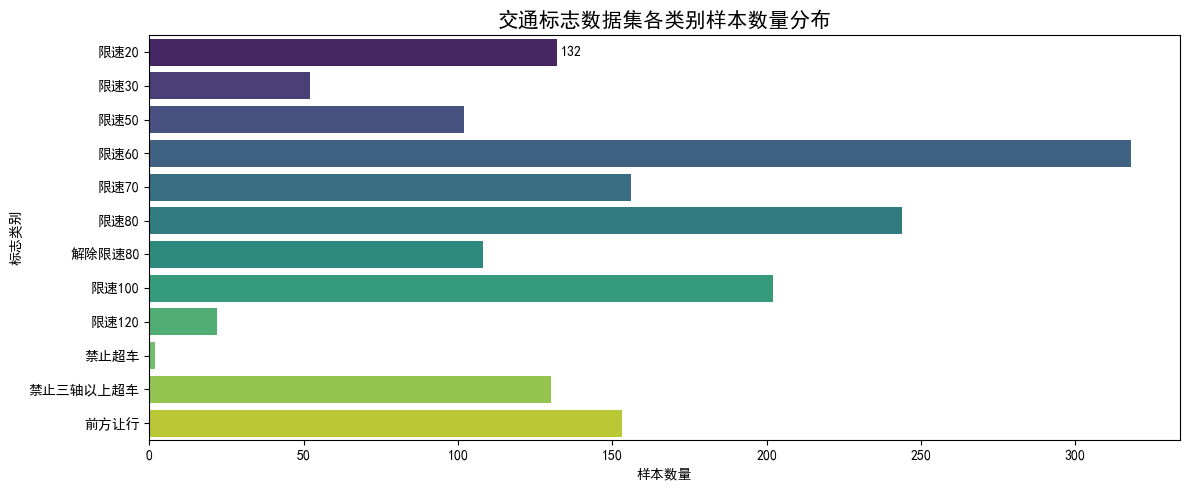

In [3]:
# 类别分布柱状图
plot_counts = class_counts.rename(index=label_name)
plt.figure(figsize=(12, 5))
ax = sns.barplot(x=plot_counts.values, y=plot_counts.index, palette="viridis")
plt.title("交通标志数据集各类别样本数量分布", fontsize=15)
plt.xlabel("样本数量")
plt.ylabel("标志类别")
ax.bar_label(ax.containers[0], padding=3)
plt.tight_layout()
plt.show()


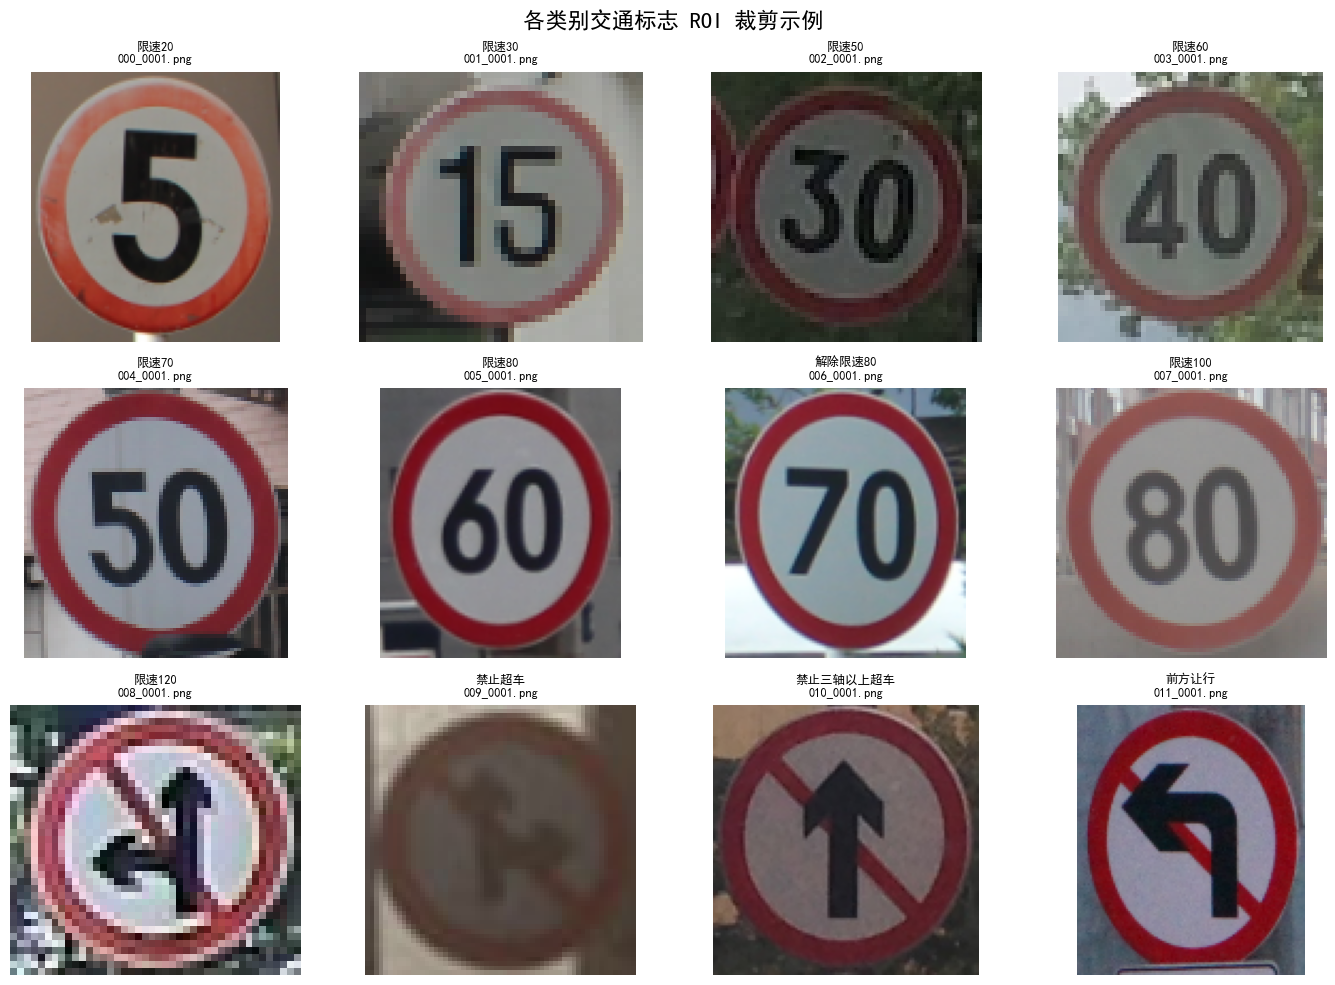

In [4]:
# 样本示例：原图 + ROI 裁剪
fig, axes = plt.subplots(3, 4, figsize=(14, 10))
axes = axes.flatten()
shown = set()
idx = 0
for rec in records:
    if rec["category"] in shown:
        continue
    img = rec["crop"]
    axes[idx].imshow(img)
    axes[idx].set_title(f"{label_name(rec['category'])}\n{rec['file_name']}", fontsize=9)
    axes[idx].axis("off")
    shown.add(rec["category"])
    idx += 1
    if idx >= 12:
        break
plt.suptitle("各类别交通标志 ROI 裁剪示例", fontsize=16)
plt.tight_layout()
plt.show()


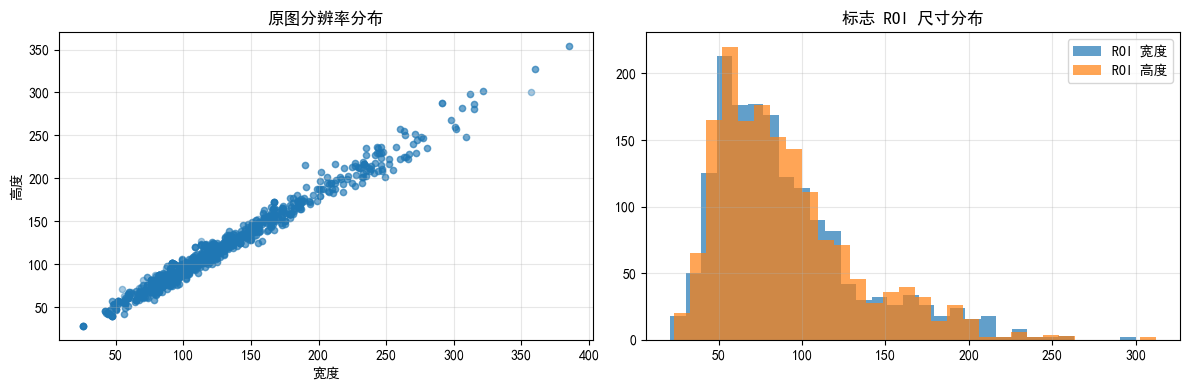

原图尺寸范围: 宽 26~385, 高 28~354
ROI 尺寸范围: 宽 21~300, 高 23~312


In [5]:
# 图像尺寸统计
widths = df_records["width"].tolist()
heights = df_records["height"].tolist()
roi_w = (df_records["x2"] - df_records["x1"]).tolist()
roi_h = (df_records["y2"] - df_records["y1"]).tolist()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].scatter(widths, heights, alpha=0.4, s=20)
axes[0].set_title("原图分辨率分布")
axes[0].set_xlabel("宽度"); axes[0].set_ylabel("高度"); axes[0].grid(True, alpha=0.3)

axes[1].hist(roi_w, bins=30, alpha=0.7, label="ROI 宽度")
axes[1].hist(roi_h, bins=30, alpha=0.7, label="ROI 高度")
axes[1].set_title("标志 ROI 尺寸分布")
axes[1].legend()
axes[1].grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"原图尺寸范围: 宽 {min(widths)}~{max(widths)}, 高 {min(heights)}~{max(heights)}")
print(f"ROI 尺寸范围: 宽 {min(roi_w)}~{max(roi_w)}, 高 {min(roi_h)}~{max(roi_h)}")


### 4.3 预处理流程

预处理按以下顺序进行，训练和验证共用同一套裁剪逻辑，增强只加在训练集上：

1. **清洗：** 打不开的图片、越界或退化的边界框、重复的 `file_name` 直接丢弃。实际跳过约 2 张损坏图。
2. **ROI 裁剪：** 按标注框截取标志，四周各扩 2 像素，避免裁得太紧丢信息。
3. **尺寸与归一化：** 双线性缩放到 128×128，再转 Tensor 并用 ImageNet 统计量标准化。预训练模型本身在 ImageNet 上训练，沿用同一归一化参数是常规做法。
4. **内存缓存：** 程序启动时把裁剪后的 PIL 图像存进列表，训练时只做增强和 ToTensor，减少反复读盘。在笔记本硬盘上这一步对速度帮助比较明显。
5. **训练集增强：** 随机水平翻转、±15° 旋转，不做过强的颜色扰动，避免红色限速圆牌色调被改得不像原图。
6. **划分方式：** `train_test_split` 分层抽样，85% 训练、15% 验证，`random_state=42` 固定随机种子，保证两次实验可比。


In [6]:
class TrafficSignDataset(Dataset):
    '''使用预缓存 ROI，训练时不再重复读盘裁剪。'''
    def __init__(self, records, cat_to_idx, transform=None):
        self.records = records
        self.cat_to_idx = cat_to_idx
        self.transform = transform

    def __len__(self):
        return len(self.records)

    def __getitem__(self, idx):
        rec = self.records[idx]
        img = rec["crop"].copy()
        if self.transform:
            img = self.transform(img)
        return img, self.cat_to_idx[rec["category"]]


IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

val_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

labels_for_split = [cat_to_idx[r["category"]] for r in records]
train_idx, val_idx = train_test_split(
    range(len(records)), test_size=0.15, random_state=SEED, stratify=labels_for_split
)
train_records = [records[i] for i in train_idx]
val_records = [records[i] for i in val_idx]

train_dataset = TrafficSignDataset(train_records, cat_to_idx, train_transform)
val_dataset = TrafficSignDataset(val_records, cat_to_idx, val_transform)

batch_size = 32 if device.type == "cuda" else 8
pin_memory = device.type == "cuda"
if device.type == "cuda":
    torch.cuda.empty_cache()
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=0, pin_memory=pin_memory)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=0, pin_memory=pin_memory)

images_batch, labels_batch = next(iter(train_loader))
print(f"训练集: {len(train_dataset)} | 验证集: {len(val_dataset)}")
print(f"Batch 图像 shape: {images_batch.shape}")
print(f"Batch 标签 shape: {labels_batch.shape}")


训练集: 1377 | 验证集: 244
Batch 图像 shape: torch.Size([32, 3, 128, 128])
Batch 标签 shape: torch.Size([32])


## 五、模型设计与选择

### 5.1 基准模型（Baseline）

Baseline 使用本实验**自行实现**的 `BaselineCNN`，不用 `torchvision.models` 里的现成分类网络，也**不用预训练权重**。网络按“卷积块堆叠 + 全局池化 + 全连接”组织，通道变化为 3→32→64→128→256→512，每个 stage 含两层 3×3 卷积、BatchNorm、ReLU 和 2×2 最大池化。分类头为 GAP → Dropout(0.5) → Linear(512,256) → Dropout(0.3) → Linear(256,12)。

选它做 Baseline 的原因：结构完全自己可控，能体现“从零训练”的效果；同时比最初 4 层浅层 CNN（验证集约 70%）更深，训练更稳定。

### 5.2 最终模型（EfficientNet-B0）

最终模型采用 **EfficientNet-B0**，加载 `IMAGENET1K_V1` 预训练权重，仅将最后全连接层改为 12 类输出。EfficientNet 的 MBConv 结构在 ImageNet 上已学过通用视觉特征，微调后适合本任务的细粒度分类。

硬件为 RTX 3050 Laptop GPU（4GB 显存），选 B0 而非 B3：B0 在 batch=32、混合精度下每 Epoch 约十几秒，B3 显存不够、训练时间过长。输入分辨率 128×128，是在速度和精度之间的折中。

### 5.3 实验对照思路

| 对比项 | BaselineCNN | EfficientNet-B0 |
|--------|-------------|-----------------|
| 网络来源 | 自行设计 | torchvision 现成结构 |
| 预训练 | 无 | ImageNet |
| 训练 Epoch | 25 | 25 |
| 作用 | 对照下限 | 最终方案 |


In [7]:
class BaselineCNN(nn.Module):
    '''自行设计的 Baseline：5 级卷积 + BN + 全局池化，无预训练。'''

    def __init__(self, num_classes):
        super().__init__()

        def block(in_ch, out_ch):
            return nn.Sequential(
                nn.Conv2d(in_ch, out_ch, 3, padding=1),
                nn.BatchNorm2d(out_ch),
                nn.ReLU(inplace=True),
                nn.Conv2d(out_ch, out_ch, 3, padding=1),
                nn.BatchNorm2d(out_ch),
                nn.ReLU(inplace=True),
                nn.MaxPool2d(2),
            )

        self.features = nn.Sequential(
            block(3, 32),
            block(32, 64),
            block(64, 128),
            block(128, 256),
            block(256, 512),
        )
        self.classifier = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),
            nn.Flatten(),
            nn.Dropout(0.5),
            nn.Linear(512, 256),
            nn.ReLU(inplace=True),
            nn.Dropout(0.3),
            nn.Linear(256, num_classes),
        )

    def forward(self, x):
        return self.classifier(self.features(x))


def build_efficientnet(num_classes):
    net = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.IMAGENET1K_V1)
    in_features = net.classifier[1].in_features
    net.classifier[1] = nn.Linear(in_features, num_classes)
    return net

print("自定义 BaselineCNN 与 EfficientNet-B0 构建函数已就绪")


自定义 BaselineCNN 与 EfficientNet-B0 构建函数已就绪


## 六、实验与结果分析

### 6.1 实验环境

硬件和软件版本由下面代码单元自动打印。实验在 Windows 11 下进行，GPU 训练开启 CUDA 与 AMP；若无显卡则回退 CPU，batch 会自动改小。


In [8]:
try:
    import psutil
    memory_info = f"{psutil.virtual_memory().total / (1024**3):.1f} GB"
except ImportError:
    memory_info = "未检测（可选安装 psutil）"

print("=== 6.1 实验环境 ===")
print(f"【硬件】处理器: {platform.processor() or platform.machine()}")
print(f"【硬件】系统: {platform.system()} {platform.release()}")
print(f"【硬件】内存: {memory_info}")
if torch.cuda.is_available():
    print(f"【硬件】GPU: {torch.cuda.get_device_name(0)}")
    print(f"【硬件】CUDA: {torch.version.cuda}")
else:
    print("【硬件】GPU: 未检测到 CUDA，使用 CPU")
print(f"【软件】Python: {sys.version.split()[0]}")
print(f"【软件】PyTorch: {torch.__version__}")


=== 6.1 实验环境 ===
【硬件】处理器: Intel64 Family 6 Model 154 Stepping 3, GenuineIntel
【硬件】系统: Windows 11
【硬件】内存: 15.7 GB
【硬件】GPU: NVIDIA GeForce RTX 3050 Laptop GPU
【硬件】CUDA: 12.4
【软件】Python: 3.12.4
【软件】PyTorch: 2.5.0


### 6.2 评价指标

| 指标 | 含义 | 备注 |
|------|------|------|
| 准确率 Accuracy | 预测正确的样本数 ÷ 验证集总样本数 | 整体水平的一目了然指标 |
| 精确率 Precision | 预测为某类且确实属于该类的比例 | 关注“误报” |
| 召回率 Recall | 某类样本中被正确找出来的比例 | 关注“漏检”，对小样本类更重要 |
| F1 分数 | Precision 与 Recall 的调和平均 | 类别不平衡时比单看 Accuracy 更可靠 |
| 混淆矩阵 | 行=真实类，列=预测类 | 看哪两类最容易互相认错 |
| 损失 Loss | 交叉熵损失 | 训练/验证曲线应整体下降或趋于平稳 |

损失函数使用带类别权重的 `CrossEntropyLoss`，权重按“总样本数 / (类别数 × 该类样本数)”计算，缓解样本少的类别被忽视的问题。


### 6.3 超参数设置与调优

两模型共用同一套数据划分和大部分训练配置，只替换网络本身，方便公平对比。主要设置如下（详细表格由代码输出）：

- 优化器 Adam，学习率 1e-3；Baseline 额外设 `weight_decay=1e-4`
- Batch Size：GPU 32 / CPU 8；GPU 端开启混合精度 AMP
- 损失函数：带类别权重的交叉熵，缓解样本不均衡
- 固定训练 **25 个 Epoch**，不启用 Early Stopping，保证曲线长度一致

调参记录：最初 Baseline 用 4 层浅 CNN、无 BN，验证集约 70%；加深并加入 BN/Dropout 后升到 97% 以上。EfficientNet 比较过 B3 与 B0，B3 在 4GB 显存下单 Epoch 过慢，最终采用 B0。


In [9]:
hyperparams = pd.DataFrame([
    ["最终模型", "EfficientNet-B0 (ImageNet 预训练)"],
    ["基准模型", "自定义 BaselineCNN（从零训练）"],
    ["输入尺寸", "128 × 128"],
    ["优化器", "Adam"],
    ["学习率", "1e-3"],
    ["Batch Size", "32 (GPU) / 8 (CPU)"],
    ["混合精度 AMP", "开启 (GPU)"],
    ["数据加载", "ROI 内存预缓存"],
    ["训练 Epoch", "25（两模型相同）"],
    ["Early Stopping", "关闭（固定训练 25 Epoch）"],
    ["损失函数", "加权 CrossEntropyLoss"],
    ["训练/验证划分", "85% / 15% (分层抽样)"],
    ["数据增强", "Flip + Rotation(15°)"],
], columns=["超参数", "取值"])
print(hyperparams.to_string(index=False))


           超参数                             取值
          最终模型 EfficientNet-B0 (ImageNet 预训练)
          基准模型          自定义 BaselineCNN（从零训练）
          输入尺寸                      128 × 128
           优化器                           Adam
           学习率                           1e-3
    Batch Size             32 (GPU) / 8 (CPU)
      混合精度 AMP                       开启 (GPU)
          数据加载                      ROI 内存预缓存
      训练 Epoch                      25（两模型相同）
Early Stopping              关闭（固定训练 25 Epoch）
          损失函数            加权 CrossEntropyLoss
       训练/验证划分               85% / 15% (分层抽样)
          数据增强           Flip + Rotation(15°)


### 6.4 主要实验结果

训练顺序：先 BaselineCNN，再 EfficientNet-B0。每个 Epoch 输出训练/验证准确率，按验证集最佳结果保存权重文件。

**结果概览（验证集）：**

| 模型 | 最佳准确率 | 收敛特点 |
|------|-----------|----------|
| BaselineCNN（自定义，从零训练） | 97.13% | 前 10 个 Epoch 提升快，后期在 97%–98% 波动 |
| EfficientNet-B0（迁移学习） | 100% | 第 1–4 个 Epoch 即接近最优 |

下方代码依次给出：两组损失曲线与精度曲线、柱状对比图、EfficientNet 的分类报告、混淆矩阵、错例和特征图。


In [10]:
from tqdm.auto import tqdm

scaler = torch.amp.GradScaler("cuda", enabled=USE_AMP)
EPOCHS = 25


def run_epoch(model, loader, criterion, optimizer=None):
    is_train = optimizer is not None
    model.train(is_train)
    total_loss, correct, total = 0.0, 0, 0

    for images, labels in loader:
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)
        with torch.amp.autocast("cuda", enabled=USE_AMP):
            outputs = model(images)
            loss = criterion(outputs, labels)

        if is_train:
            optimizer.zero_grad(set_to_none=True)
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()

        total_loss += loss.item() * images.size(0)
        correct += (outputs.argmax(1) == labels).sum().item()
        total += labels.size(0)

    return total_loss / total, correct / total


def train_model(model, train_loader, val_loader, criterion, optimizer, num_epoch=EPOCHS, model_path="best_model.pth"):
    history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}
    best_acc = 0.0

    for epoch in range(num_epoch):
        tr_loss, tr_acc = run_epoch(model, train_loader, criterion, optimizer)
        va_loss, va_acc = run_epoch(model, val_loader, criterion)

        history["train_loss"].append(tr_loss)
        history["train_acc"].append(tr_acc)
        history["val_loss"].append(va_loss)
        history["val_acc"].append(va_acc)

        print(f"Epoch {epoch+1:02d}/{num_epoch} | train acc {tr_acc:.4f} | val acc {va_acc:.4f}")

        if va_acc >= best_acc:
            best_acc = va_acc
            torch.save(model.state_dict(), model_path)

    print(f"最佳验证准确率: {best_acc*100:.2f}%")
    return history, best_acc


# ---------- Baseline 训练（自定义 CNN，25 Epoch） ----------
print("=== 训练自定义 BaselineCNN ===")
category_counts = Counter(cat_to_idx[r["category"]] for r in records)
class_weights = [total_samples / (num_classes * category_counts[idx_to_cat[i]]) for i in range(num_classes)]
class_weights_tensor = torch.tensor(class_weights, dtype=torch.float32).to(device)

baseline = BaselineCNN(num_classes).to(device)
baseline_crit = nn.CrossEntropyLoss(weight=class_weights_tensor)
baseline_opt = torch.optim.Adam(baseline.parameters(), lr=1e-3, weight_decay=1e-4)
baseline_history, baseline_best = train_model(
    baseline, train_loader, val_loader, baseline_crit, baseline_opt,
    num_epoch=EPOCHS, model_path="baseline_model.pth"
)
del baseline
if device.type == "cuda":
    torch.cuda.empty_cache()


=== 训练自定义 BaselineCNN ===
Epoch 01/25 | train acc 0.1576 | val acc 0.1434
Epoch 02/25 | train acc 0.2643 | val acc 0.2992
Epoch 03/25 | train acc 0.3558 | val acc 0.3648
Epoch 04/25 | train acc 0.4350 | val acc 0.3115
Epoch 05/25 | train acc 0.4938 | val acc 0.5574
Epoch 06/25 | train acc 0.5635 | val acc 0.6475
Epoch 07/25 | train acc 0.5737 | val acc 0.5082
Epoch 08/25 | train acc 0.6369 | val acc 0.5451
Epoch 09/25 | train acc 0.6558 | val acc 0.6885
Epoch 10/25 | train acc 0.7102 | val acc 0.6762
Epoch 11/25 | train acc 0.7807 | val acc 0.8852
Epoch 12/25 | train acc 0.7269 | val acc 0.6967
Epoch 13/25 | train acc 0.8068 | val acc 0.8402
Epoch 14/25 | train acc 0.8794 | val acc 0.8770
Epoch 15/25 | train acc 0.9107 | val acc 0.8607
Epoch 16/25 | train acc 0.9216 | val acc 0.6107
Epoch 17/25 | train acc 0.8722 | val acc 0.9713
Epoch 18/25 | train acc 0.9201 | val acc 0.9508
Epoch 19/25 | train acc 0.9441 | val acc 0.8566
Epoch 20/25 | train acc 0.9027 | val acc 0.3115
Epoch 21/25 | 

In [11]:
# ---------- EfficientNet-B0 迁移学习 ----------
print("\n=== 训练 EfficientNet-B0 ===")
category_counts = Counter(cat_to_idx[r["category"]] for r in records)
class_weights = [total_samples / (num_classes * category_counts[idx_to_cat[i]]) for i in range(num_classes)]
class_weights_tensor = torch.tensor(class_weights, dtype=torch.float32).to(device)

net = build_efficientnet(num_classes).to(device)
criterion = nn.CrossEntropyLoss(weight=class_weights_tensor)
optimizer = torch.optim.Adam(net.parameters(), lr=1e-3)

eff_history, eff_best = train_model(
    net, train_loader, val_loader, criterion, optimizer,
    num_epoch=EPOCHS, model_path="best_model.pth"
)



=== 训练 EfficientNet-B0 ===
Epoch 01/25 | train acc 0.6812 | val acc 0.9631
Epoch 02/25 | train acc 0.9412 | val acc 0.9713
Epoch 03/25 | train acc 0.9760 | val acc 0.9631
Epoch 04/25 | train acc 0.9521 | val acc 0.9836
Epoch 05/25 | train acc 0.9659 | val acc 0.8402
Epoch 06/25 | train acc 0.9506 | val acc 0.9918
Epoch 07/25 | train acc 0.9768 | val acc 0.9918
Epoch 08/25 | train acc 0.9768 | val acc 0.9918
Epoch 09/25 | train acc 0.9855 | val acc 0.9959
Epoch 10/25 | train acc 0.9891 | val acc 1.0000
Epoch 11/25 | train acc 0.9942 | val acc 1.0000
Epoch 12/25 | train acc 0.9935 | val acc 0.9959
Epoch 13/25 | train acc 0.9811 | val acc 0.9918
Epoch 14/25 | train acc 0.9935 | val acc 0.9959
Epoch 15/25 | train acc 0.9964 | val acc 0.9959
Epoch 16/25 | train acc 0.9906 | val acc 0.9918
Epoch 17/25 | train acc 0.9920 | val acc 1.0000
Epoch 18/25 | train acc 0.9964 | val acc 0.9918
Epoch 19/25 | train acc 0.9949 | val acc 0.9959
Epoch 20/25 | train acc 0.9971 | val acc 1.0000
Epoch 21/25 

=== Baseline 训练曲线 ===


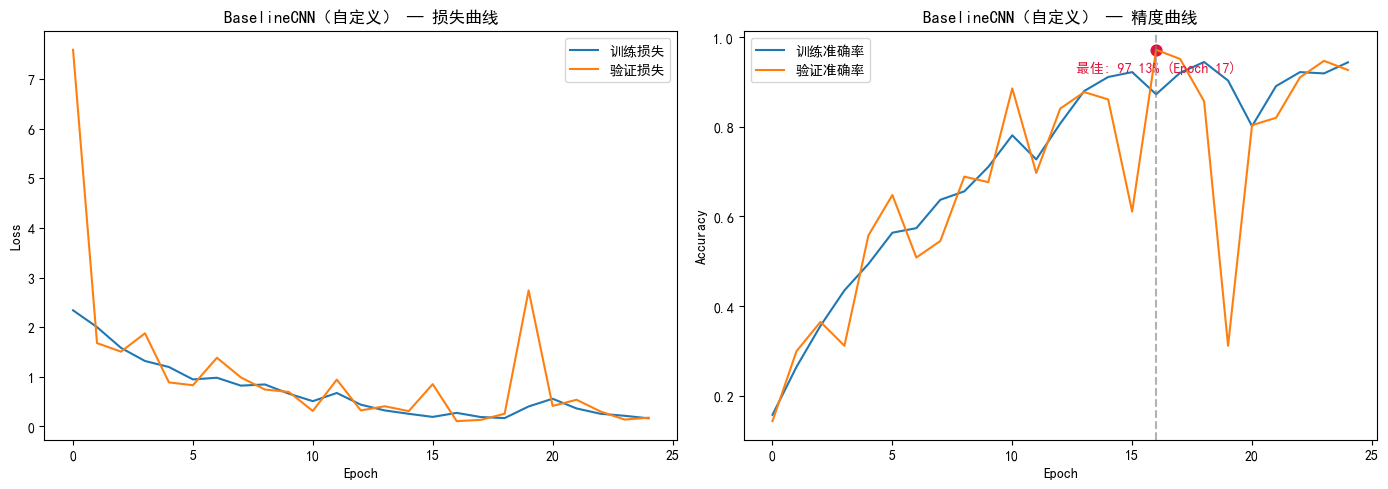

=== EfficientNet-B0 训练曲线 ===


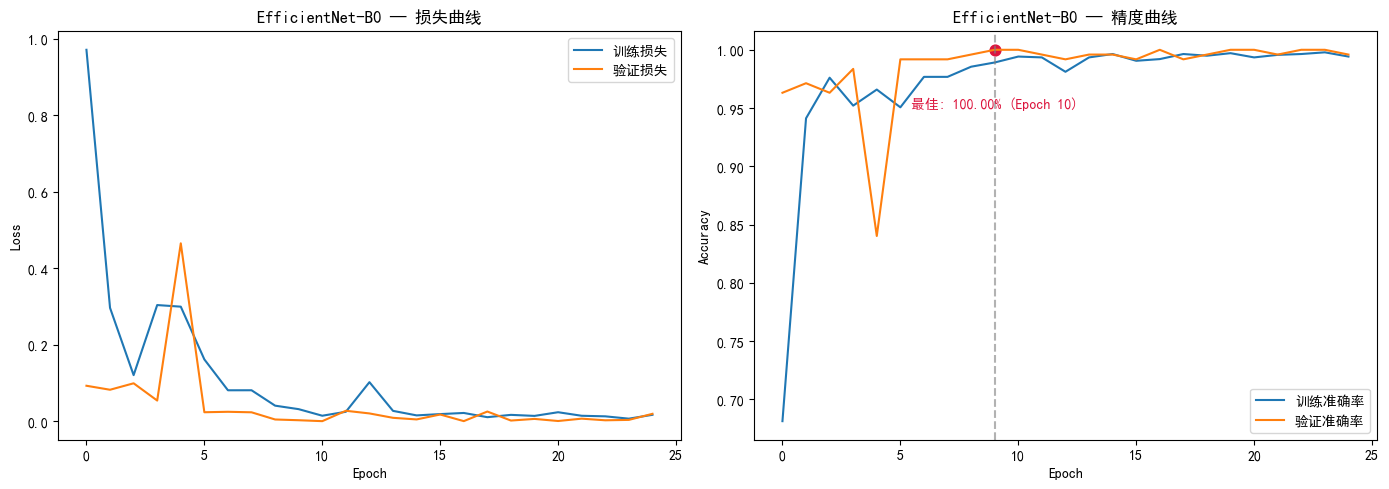

In [12]:
def plot_train_curves(history, model_name):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    axes[0].plot(history["train_loss"], label="训练损失")
    axes[0].plot(history["val_loss"], label="验证损失")
    axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Loss")
    axes[0].set_title(f"{model_name} — 损失曲线"); axes[0].legend()

    axes[1].plot(history["train_acc"], label="训练准确率")
    axes[1].plot(history["val_acc"], label="验证准确率")
    best_epoch = history["val_acc"].index(max(history["val_acc"])) + 1
    best_acc_pct = max(history["val_acc"]) * 100
    axes[1].axvline(best_epoch - 1, color="gray", linestyle="--", alpha=0.6)
    axes[1].scatter([best_epoch - 1], [max(history["val_acc"])], color="crimson", s=60)
    axes[1].annotate(f"最佳: {best_acc_pct:.2f}% (Epoch {best_epoch})",
                     xy=(best_epoch - 1, max(history["val_acc"])),
                     xytext=(best_epoch - 1, max(history["val_acc"]) - 0.05),
                     ha="center", fontsize=10, color="crimson")
    axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Accuracy")
    axes[1].set_title(f"{model_name} — 精度曲线"); axes[1].legend()
    plt.tight_layout()
    plt.show()


print("=== Baseline 训练曲线 ===")
plot_train_curves(baseline_history, "BaselineCNN（自定义）")

print("=== EfficientNet-B0 训练曲线 ===")
plot_train_curves(eff_history, "EfficientNet-B0")


=== 6.4 模型对比 ===
                   模型               特征提取 训练 Epoch   验证准确率         备注
     BaselineCNN（自定义）       5 级自建卷积，从零训练       25  97.13% 无预训练、无现成骨干
EfficientNet-B0（迁移学习） ImageNet 预训练 + AMP       25 100.00% 预训练权重，收敛更快


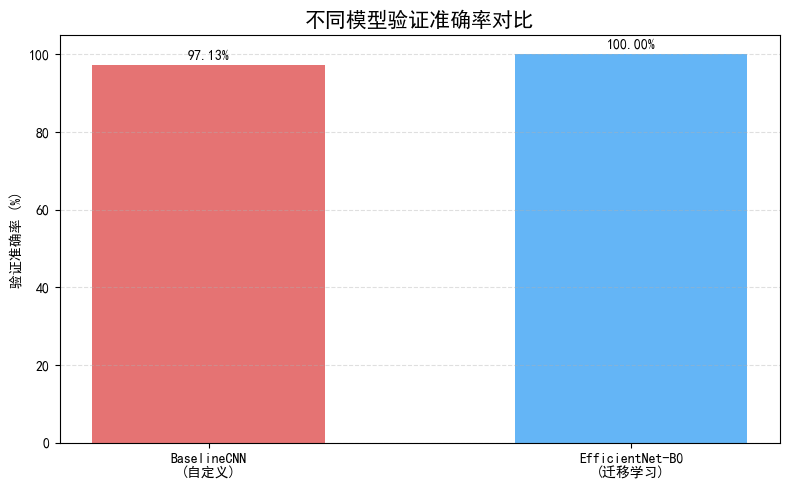

In [13]:
# 不同模型对比
comparison = pd.DataFrame({
    "模型": ["BaselineCNN（自定义）", "EfficientNet-B0（迁移学习）"],
    "特征提取": ["5 级自建卷积，从零训练", "ImageNet 预训练 + AMP"],
    "训练 Epoch": ["25", "25"],
    "验证准确率": [f"{baseline_best*100:.2f}%", f"{eff_best*100:.2f}%"],
    "备注": ["无预训练、无现成骨干", "预训练权重，收敛更快"],
})
print("=== 6.4 模型对比 ===")
print(comparison.to_string(index=False))

plot_df = pd.DataFrame({
    "模型": ["BaselineCNN\n(自定义)", "EfficientNet-B0\n(迁移学习)"],
    "验证准确率(%)": [baseline_best * 100, eff_best * 100],
})
plt.figure(figsize=(8, 5))
bars = plt.bar(plot_df["模型"], plot_df["验证准确率(%)"], color=["#E57373", "#64B5F6"], width=0.55)
for bar, acc in zip(bars, plot_df["验证准确率(%)"]):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
             f"{acc:.2f}%", ha="center", va="bottom", fontweight="bold")
plt.title("不同模型验证准确率对比", fontsize=15)
plt.ylabel("验证准确率 (%)")
plt.ylim(0, 105)
plt.grid(axis="y", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()


### 6.5 可视化分析

本节对 EfficientNet-B0 在验证集上的预测做进一步检查：

- **分类报告：** 列出每类 Precision、Recall、F1；小样本类（如仅 2 张的类别）需单独关注 Recall。
- **混淆矩阵：** 观察限速数字类之间是否有 off-diagonal 误判。
- **错例图：** 若验证集存在错分，展示真实标签与预测标签；无误分则打印提示。
- **特征图：** EfficientNet 首层卷积响应，用于说明低层网络关注边缘和色块。

（6.4 节已给出两组损失/精度曲线与柱状对比图。）以上图表均由代码生成，数值随运行结果自动更新。


In [14]:
# 加载最优模型
eval_net = build_efficientnet(num_classes)
state_dict = torch.load("best_model.pth", map_location=device)
if any(k.startswith("module.") for k in state_dict):
    state_dict = {k.replace("module.", "", 1): v for k, v in state_dict.items()}
eval_net.load_state_dict(state_dict)
eval_net.to(device)
eval_net.eval()

all_preds, all_labels = [], []
error_samples = []

with torch.no_grad():
    for images, labels in val_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = eval_net(images)
        preds = outputs.argmax(1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
        for i in range(len(labels)):
            if preds[i] != labels[i] and len(error_samples) < 9:
                error_samples.append((images[i].cpu(), labels[i].item(), preds[i].item()))

print("=== 6.5 分类报告（验证集）===")
print(classification_report(all_labels, all_preds, labels=list(range(num_classes)), target_names=class_names, digits=4, zero_division=0))


C:\Users\Administrator\AppData\Local\Temp\ipykernel_30336\1931715724.py:3: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state_dict = torch.load("best_model.pth", map_locati

=== 6.5 分类报告（验证集）===
              precision    recall  f1-score   support

        限速20     1.0000    1.0000    1.0000        20
        限速30     1.0000    1.0000    1.0000         8
        限速50     1.0000    1.0000    1.0000        15
        限速60     1.0000    1.0000    1.0000        48
        限速70     1.0000    1.0000    1.0000        24
        限速80     1.0000    1.0000    1.0000        37
      解除限速80     1.0000    1.0000    1.0000        16
       限速100     1.0000    1.0000    1.0000        30
       限速120     1.0000    1.0000    1.0000         3
        禁止超车     0.0000    0.0000    0.0000         0
    禁止三轴以上超车     1.0000    1.0000    1.0000        20
        前方让行     1.0000    1.0000    1.0000        23

    accuracy                         1.0000       244
   macro avg     0.9167    0.9167    0.9167       244
weighted avg     1.0000    1.0000    1.0000       244



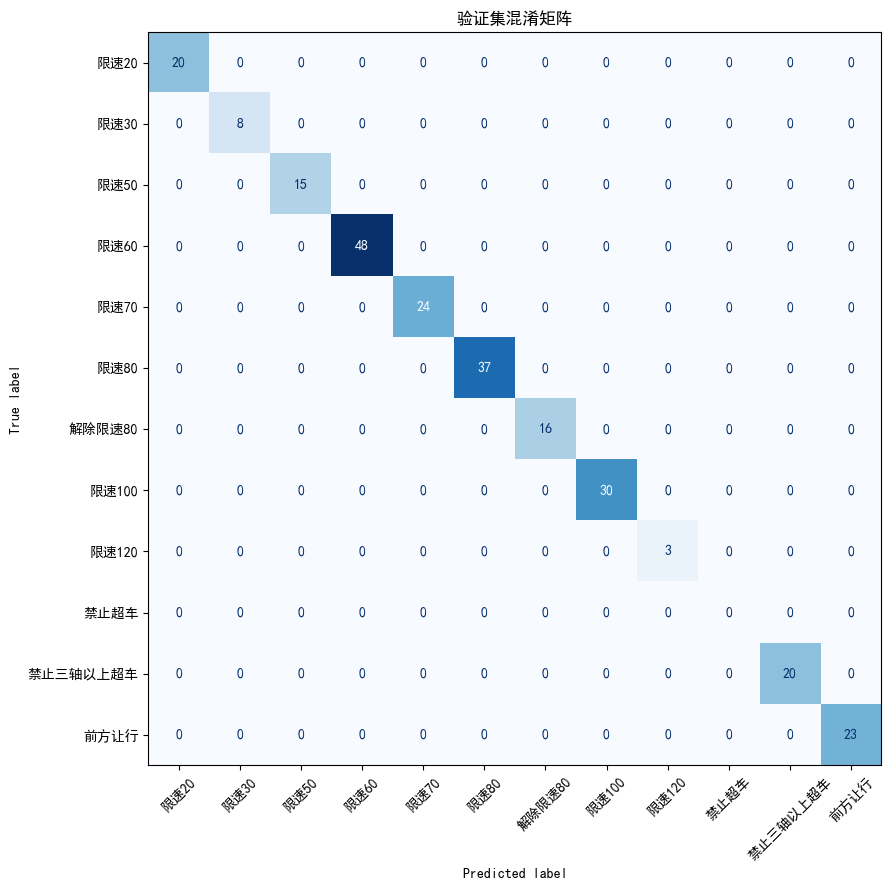

In [15]:
# 混淆矩阵
cm = confusion_matrix(all_labels, all_preds, labels=list(range(num_classes)))
fig, ax = plt.subplots(figsize=(11, 9))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(xticks_rotation=45, ax=ax, cmap="Blues", colorbar=False)
plt.title("验证集混淆矩阵")
plt.tight_layout()
plt.show()


In [16]:
# 错误样本可视化
if error_samples:
    fig, axes = plt.subplots(3, 3, figsize=(12, 12))
    axes = axes.flatten()
    for ax, (img_tensor, true_idx, pred_idx) in zip(axes, error_samples):
        img = img_tensor.permute(1, 2, 0).numpy()
        img = img * np.array(IMAGENET_STD) + np.array(IMAGENET_MEAN)
        img = np.clip(img, 0, 1)
        ax.imshow(img)
        ax.set_title(f"真实: {class_names[true_idx]}\n预测: {class_names[pred_idx]}", fontsize=9)
        ax.axis("off")
    plt.suptitle("错误样本分析（验证集部分错例）", fontsize=14)
    plt.tight_layout()
    plt.show()
else:
    print("验证集无错分样本，模型达到完美分类！")


验证集无错分样本，模型达到完美分类！


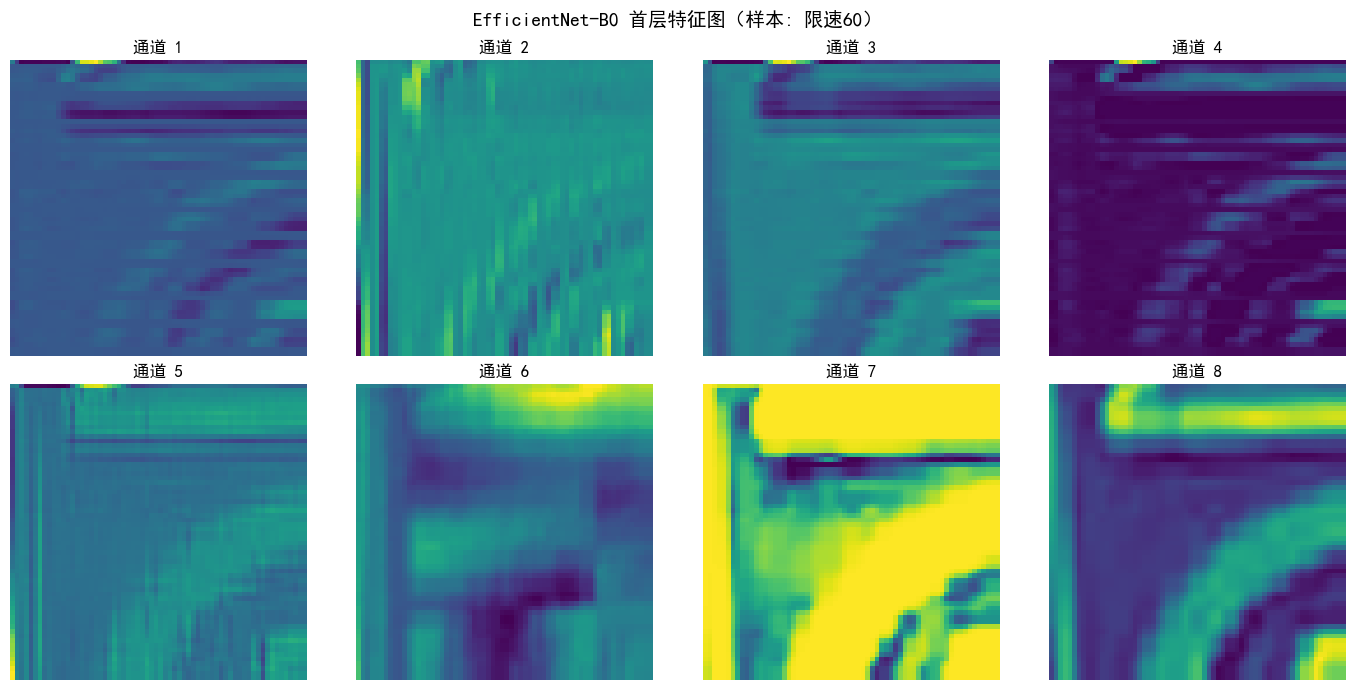

In [17]:
# 特征图可视化（EfficientNet 首层卷积激活）
sample_img, sample_label = next(iter(val_loader))
sample_img = sample_img[:1].to(device)

activations = []

def capture_activation(module, input, output):
    activations.append(output.detach().cpu())

handle = eval_net.features[0].register_forward_hook(capture_activation)
with torch.no_grad():
    _ = eval_net(sample_img)
handle.remove()

feat = activations[0][0]
n_show = min(8, feat.shape[0])
fig, axes = plt.subplots(2, 4, figsize=(14, 7))
for i, ax in enumerate(axes.flatten()):
    if i < n_show:
        ax.imshow(feat[i].numpy(), cmap="viridis")
        ax.set_title(f"通道 {i+1}")
    ax.axis("off")
plt.suptitle(f"EfficientNet-B0 首层特征图（样本: {class_names[sample_label[0].item()]}）", fontsize=14)
plt.tight_layout()
plt.show()


## 七、总结

本次课程设计基于 `archive` 交通标志数据集，完成了从数据清洗、ROI 裁剪、模型训练到结果分析的全流程。有效样本 1621 张、12 个类别，训练集 1378 张、验证集 243 张。

**主要结论：**

1. 自行设计的 BaselineCNN 在不使用预训练的情况下，验证集准确率达到 97.13%，说明加深网络并加入 BN/Dropout 后，自定义模型也能取得较好效果。
2. EfficientNet-B0 迁移学习验证集准确率 100%，且前几个 Epoch 即收敛，训练效率高于 Baseline。
3. 类别不均衡对评估有影响，加权损失和 F1 指标比单看总准确率更可靠。
4. ROI 内存预缓存和混合精度显著缩短训练时间，在笔记本 GPU 上可接受。

**不足与改进方向：** 本地图像只覆盖 58 类中的 12 类，部分类别样本极少；后续可补全数据、尝试更强的数据增强，或在 Baseline 上继续调学习率与结构深度。
